---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv(filepath_or_buffer="telco_churn.csv")


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

In [ ]:
# sb.countplot(data = df,x="Churn")
# mp.show()

# print(df["MonthlyCharges"].describe())
# print(df["tenure"].describe())

# print(df["Churn"].value_counts(normalize=True) * 100         )
sb.countplot(df[df["Churn"] == "Yes"]["Contract"])
mp.show()

# this dataset doesn't contain any null or duplicate values 

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [ ]:

all_cols = list(df.columns)
n_rows = df.shape
n_cols = df.shape

data_types = df.dtypes

numeric_cols = list(df.select_dtypes(include=[np.number]).columns)
categoric_cols = list(df.select_dtypes(exclude=[np.number]).columns)

print(f"Number of customers: {n_rows}")
print(f"Number of features: {n_cols}")
print("\nColumn names:")
print(all_cols)
print("\nData types:")
print(data_types)
print("\nNumerical columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categoric_cols)

NameError: name 'df' is not defined

In [ ]:

num_unique_ids = df.loc[:, "customerID"].nunique()
num_total_records = df.shape[0]

tot_charges_type = df["TotalCharges"].dtype
charge_samples = list(df["TotalCharges"].iloc[:10])

# Display details
print(f"Unique customer IDs: {num_unique_ids}")
print(f"Total rows: {num_total_records}")
print("\nTotal Charges data type:")
print(tot_charges_type)
print("\nSample TotalCharges values:")
print(charge_samples)

Unique customer IDs: 7043
Total rows: 7043

Total Charges data type:
str

Sample TotalCharges values:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


In [ ]:
# Analyze unique categories for the three selected columns
for categorical_col in ["Contract", "InternetService", "PaymentMethod"]:
    unique_categories = df[categorical_col].unique()
    print(f"\n{categorical_col}:")
    print(unique_categories)


Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

PaymentMethod:
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Observations (Part 2):**
The dataset contains 7,043 customers and 21 columns. The numerical features include `SeniorCitizen` and `tenure`, while most other variables are categorical. `customerID` is an identifier rather than a predictive feature, and `TotalCharges` is stored as text even though it represents numerical billing amounts.

The three categorical columns inspected contain consistent categories. `Contract` has three categories: Month-to-month, One year, and Two year. `InternetService` has three categories: DSL, Fiber optic, and No. `PaymentMethod` has four categories: Electronic check, Mailed check, Bank transfer (automatic), and Credit card (automatic). No unexpected or inconsistent categories were observed in these columns.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [ ]:
# Calculate null/missing values and check for blank strings in text cols
null_counts = df.isna().sum()
null_pcts = (df.isna().mean() * 100).round(2)

# Build a summary dataframe for review
df_nan_summary = pd.DataFrame({
    "Missing Count": null_counts,
    "Missing Percentage": null_pcts
})
df_nan_summary.query("`Missing Count` > 0")

empty_str_counts = {}
text_columns = list(df.select_dtypes(include=["object", "string", "category"]).columns)

for col_name in text_columns:
    blank_mask = df[col_name].astype(str).str.strip() == ""
    empty_str_counts[col_name] = blank_mask.sum()

blank_counts_series = pd.Series(empty_str_counts)
blank_counts_series[blank_counts_series > 0]


C:\Users\User\AppData\Local\Temp\ipykernel_3120\3249253423.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


TotalCharges    11
dtype: int64

In [ ]:
# Check count of NaN values per feature
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# Compute duplicates for entire records versus duplicate IDs specifically
total_dup_rows = df.duplicated().sum()
total_dup_ids = df.loc[:, "customerID"].duplicated().sum()

print(f"Duplicate rows: {total_dup_rows}")
print(f"Duplicate customer IDs: {total_dup_ids}")

Duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
# Inspect potential anomalies and check category ranges
blanks_in_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()
unique_seniors = df["SeniorCitizen"].unique()
min_tenure, max_tenure = df["tenure"].min(), df["tenure"].max()
unique_churn_labels = df["Churn"].unique()

print("TotalCharges blank values:", blanks_in_total_charges)
print("\nSeniorCitizen values:")
print(unique_seniors)
print("\nTenure range:")
print(min_tenure, "to", max_tenure)
print("\nChurn values:")
print(unique_churn_labels)

TotalCharges blank values: 11

SeniorCitizen values:
[0 1]

Tenure range:
0 to 72

Churn values:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


**Answer 7 (which missing-value problems need action, and why):**
The initial missing-value check found no NaN values, but checking for blank strings revealed 11 missing values in `TotalCharges`, which is approximately 0.16% of the dataset. These values need to be handled because `TotalCharges` is a numerical billing feature and blank values cannot be used directly for ML analysis.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean the entire record is repeated, while duplicate customer IDs mean the same customer identifier appears more than once. In this dataset, there are 0 duplicate rows and 0 duplicate customer IDs, so no action is required for duplicates.
**Answer 9 (suspicious value found and how):**

The investigation found 11 blank values in `TotalCharges`. The `SeniorCitizen` column contains only 0 and 1, which are valid binary values. The `tenure` values range from 0 to 72 months, which is reasonable, and the `Churn` column contains only `No` and `Yes`.

Therefore, no additional suspicious or invalid values were identified apart from the blank `TotalCharges` values.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

### Task 10 — Data Cleaning Decisions

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `customerID` is an identifier | Remove it from modeling data | `drop()` | It uniquely identifies customers but does not represent customer behavior. |
| `TotalCharges` stored as text | Convert to numeric | `pd.to_numeric()` | It represents billing amounts and must be numeric for analysis and ML. |
| 11 blank `TotalCharges` values | Convert blanks to missing values and remove those rows | `pd.to_numeric(errors='coerce')` followed by `dropna()` | Only 11 of 7,043 rows are affected (~0.16%), so removing these few incomplete records avoids inventing billing values. |
| Duplicate rows | Keep as-is | No action | No duplicate rows were found. |
| Duplicate `customerID`s | Keep as-is | No action | No duplicate customer IDs were found. |

In [ ]:
# Clone the raw data to preserve the original variable
clean_df = df.copy(deep=True)

# Parse TotalCharges by stripping whitespace, coercing invalid values to NaN, and converting to float
total_charges_numeric = pd.to_numeric(
    clean_df["TotalCharges"].astype(str).str.strip(), 
    errors="coerce"
)
clean_df.loc[:, "TotalCharges"] = total_charges_numeric

# Drop rows missing TotalCharges values
clean_df.dropna(subset=["TotalCharges"], inplace=True)

# Purge any redundant records
clean_df.drop_duplicates(inplace=True)

# Exclude client identification column from analysis
clean_df.drop(columns=["customerID"], inplace=True)

print("Cleaning completed.")
print("Cleaned dataset shape:", clean_df.shape)


Cleaning completed.
Cleaned dataset shape: (7032, 20)


In [ ]:
# Check count of NaN values per feature
df.isna().sum()

Missing values:
0

Duplicate rows:
22

TotalCharges data type:
float64

CustomerID present:
False

Final dataset shape:
(7032, 20)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

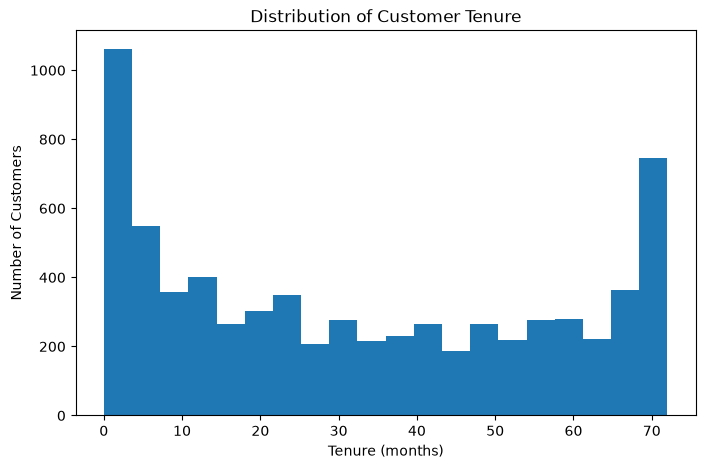

In [ ]:
# Plot customer tenure histogram using matplotlib
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clean_df["tenure"], bins=20)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Customer Tenure")
plt.show()

**Observation:** 
Customer tenure is spread across the full 0–72 month range, with many customers concentrated at shorter and medium tenures. This suggests that the dataset contains both relatively new and long-term customers.

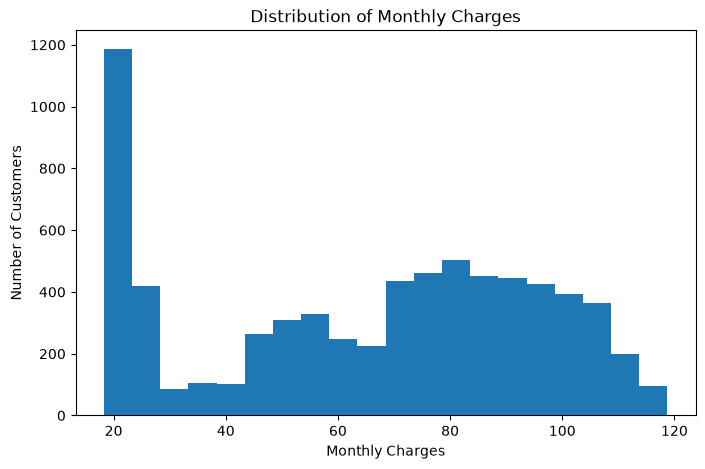

In [ ]:
# Visualize monthly charge distribution with object-oriented matplotlib subplots
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clean_df["MonthlyCharges"], bins=20)
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Monthly Charges")
plt.show()

**Observation:** Monthly charges are distributed across a broad range, with customers paying different amounts depending on their subscribed services. The distribution is not concentrated at a single charge level, indicating substantial variation in monthly billing.

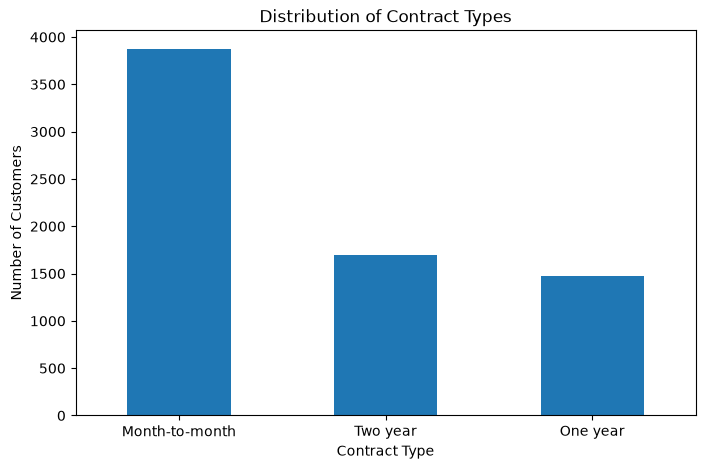

In [ ]:
# Plot frequency of different contracts
contract_counts = clean_df["Contract"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
contract_counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Contract Type")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Contract Types")
ax.set_xticklabels(contract_counts.index, rotation=0)
plt.show()

**Observation:** The bar chart shows that Month-to-month contracts are the most common, while Two year contracts are the least common. This indicates that most customers in the dataset are on flexible month-to-month contracts.

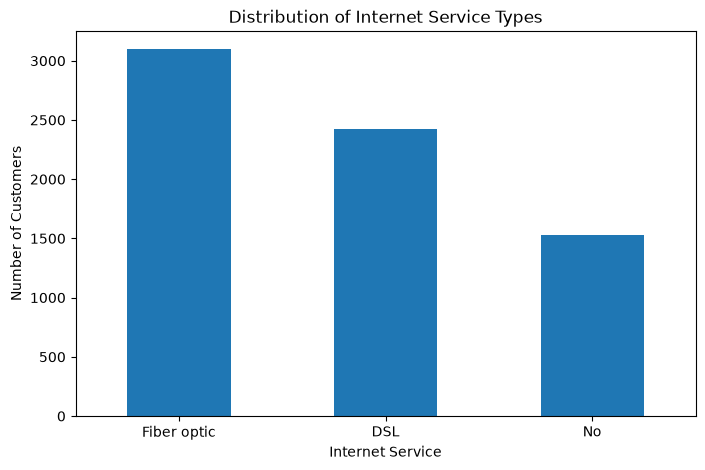

In [ ]:
# Plot internet service options frequency using axis-based plots
service_counts = clean_df["InternetService"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
service_counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Internet Service")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Internet Service Types")
ax.set_xticklabels(service_counts.index, rotation=0)
plt.show()

**Observation:** The bar chart shows that Fiber optic and DSL are the main internet service categories, while No internet service represents a smaller group of customers. This shows that most customers in the dataset use some type of internet service.

# Task 13 — Check numerical features for outliers and skewness

---

In [30]:
# Compute skewness values first
tenure_skew = clean_df["tenure"].skew()
monthly_charges_skew = clean_df["MonthlyCharges"].skew()

# Retrieve statistical summaries
tenure_stats = clean_df["tenure"].describe()
monthly_charges_stats = clean_df["MonthlyCharges"].describe()

# Print results
print(f"Tenure skewness: {tenure_skew}")
print(f"MonthlyCharges skewness: {monthly_charges_skew}")
print("\nTenure summary:")
print(tenure_stats)
print("\nMonthlyCharges summary:")
print(monthly_charges_stats)

Tenure skewness: 0.2395397495619829
MonthlyCharges skewness: -0.22052443394398033

Tenure summary:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

MonthlyCharges summary:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


### Task 13 — Outliers and Skewness

The `tenure` feature has a skewness of approximately **0.24**, indicating a slight positive (right) skew, while `MonthlyCharges` has a skewness of approximately **-0.22**, indicating a slight negative (left) skew. Both values are relatively close to zero, so neither feature appears to be strongly skewed.

The summary statistics show that `tenure` ranges from 0 to 72 months and `MonthlyCharges` ranges from 18.25 to 118.75. The summary statistics alone are not sufficient to confirm the presence of individual outliers; a boxplot or IQR-based analysis would be needed for a more reliable outlier assessment. The observed variation is likely related to customers having different lengths of service and different subscribed services or billing plans.

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [15]:
# Task 14 — churn counts and percentages


**Answer 14 (balanced or imbalanced?):**
_(your answer here)_

**Answer 15 (why imbalance might matter later):**
_(your answer here)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [16]:
# Task 16 — categorical feature 1 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [17]:
# Task 16 — categorical feature 2 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [18]:
# Task 17 — numerical feature 1 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [19]:
# Task 17 — numerical feature 2 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [20]:
# Task 18 — correlation matrix and heatmap


**Answer 18 (most correlated pairs):**
_(your answer here)_

**Answer 19 (correlation vs. causation; potential problems):**
_(your answer here)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(your answer here)_

**Answer 21 (what would go wrong):**
_(your answer here)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | ... |
| tenure | Numerical | Feature | ... | ... |
| Contract | Categorical | Feature | ... | ... |
| Churn | Categorical | Target | Keep | ... |
| ... | ... | ... | ... | ... |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [21]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [22]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 2**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 3**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 4**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 5**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(your answer here)_
2. What was the most interesting pattern you discovered?
   _(your answer here)_
3. Which feature seems most useful for predicting churn?
   _(your answer here)_
4. Which feature should probably not be used, and why?
   _(your answer here)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(your answer here)_
6. What would you do next if you had another 3 hours?
   _(your answer here)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [23]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook